# 01 — Análise Exploratória (EDA)

Exploração inicial da base de tweets em pt-BR. Lógica de produção vive em `src/`; aqui apenas exploramos.

> **Atenção ao *leakage*:** os rótulos vêm de emoticons/hashtags (`query_used`) presentes no próprio texto. A limpeza (`src/preprocessing`) os remove antes da modelagem.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from src.config.paths import get_paths
from src.data.loader import load_raw_tweets
from src.preprocessing.cleaning import clean_tweet

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

In [2]:
paths = get_paths()
df = load_raw_tweets(paths.raw_labeled, sample_size=50_000, seed=RANDOM_SEED)
df.head()

id,tweet_text,tweet_date,sentiment,query_used
i64,str,str,str,str
1031760658600284160,"""@fefocaires se és feliz trabal…","""Tue Aug 21 04:31:24 +0000 2018""","""Positivo""",""":)"""
1031760000501276674,"""Gostei de um vídeo @YouTube ht…","""Tue Aug 21 04:28:47 +0000 2018""","""Positivo""",""":)"""
1031759178350690304,"""@savvasmor mmmmmm iperoxos out…","""Tue Aug 21 04:25:31 +0000 2018""","""Positivo""",""":)"""
1031758707733004288,"""Se tu diz :D""","""Tue Aug 21 04:23:39 +0000 2018""","""Positivo""",""":)"""
1031761722766487552,"""@yixingtoxic Os resultados das…","""Tue Aug 21 04:35:38 +0000 2018""","""Positivo""",""":)"""


## Distribuição de sentimento

In [3]:
dist = df.group_by("sentiment").len().sort("len", descending=True)
dist

sentiment,len
str,u32
"""Negativo""",33150
"""Positivo""",16850


## Efeito da limpeza (antes x depois)

In [4]:
amostra = df.get_column("tweet_text").head(5).to_list()
for texto in amostra:
    print("BRUTO :", texto)
    print("LIMPO :", clean_tweet(texto))
    print("-" * 60)

BRUTO : @fefocaires se és feliz trabalhando nisso então não pare se as pessoas se incomodam com sua opinião é pq elas te dão ouvido e seu trabalho tem um grande alcance :)
LIMPO : se és feliz trabalhando nisso então não pare se as pessoas se incomodam com sua opinião é pq elas te dão ouvido e seu trabalho tem um grande alcance
------------------------------------------------------------
BRUTO : Gostei de um vídeo @YouTube https://t.co/FGEgHwa67q(🔴LIVE) FORTNITE DA NIGHT :D - LEOZERA - PC
LIMPO : gostei de um vídeo https t.co/fgeghwa67q(🔴live) fortnite da night - leozera - pc
------------------------------------------------------------
BRUTO : @savvasmor mmmmmm iperoxos oute sto alepoxori nasouna :)
LIMPO : mm ipero s oute sto alepo ri nasouna
------------------------------------------------------------
BRUTO : Se tu diz :D
LIMPO : se tu diz
------------------------------------------------------------
BRUTO : @yixingtoxic Os resultados das pesquisas se baseia no que você anda assistindo

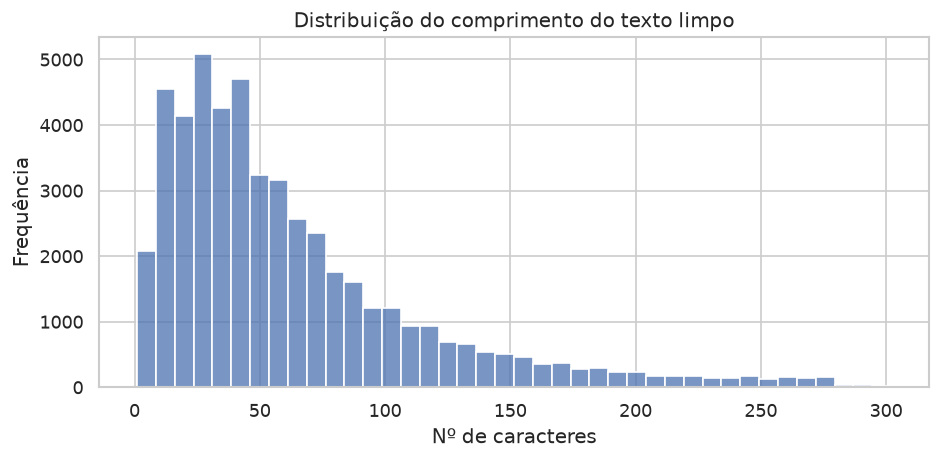

In [5]:
comprimentos = (
    df.with_columns(
        pl.col("tweet_text")
        .map_elements(lambda t: len(clean_tweet(t)), return_dtype=pl.Int64)
        .alias("len_limpo")
    )
    .get_column("len_limpo")
    .to_numpy()
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(comprimentos, bins=40, ax=ax)
ax.set_title("Distribuição do comprimento do texto limpo")
ax.set_xlabel("Nº de caracteres")
ax.set_ylabel("Frequência")
plt.tight_layout()